In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [3]:
fashion_mnist = fetch_openml(
    "Fashion-MNIST",
    version=1,
    as_frame=False
)

X = fashion_mnist.data
y = fashion_mnist.target.astype(np.int64)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)


Dataset shape: (70000, 784)
Target shape: (70000,)


In [4]:
X = X.astype("float32")
X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())


Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
X_train = X[:60000]
y_train = y[:60000]

X_test = X[60000:]
y_test = y[60000:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (60000, 784)
Testing data: (10000, 784)


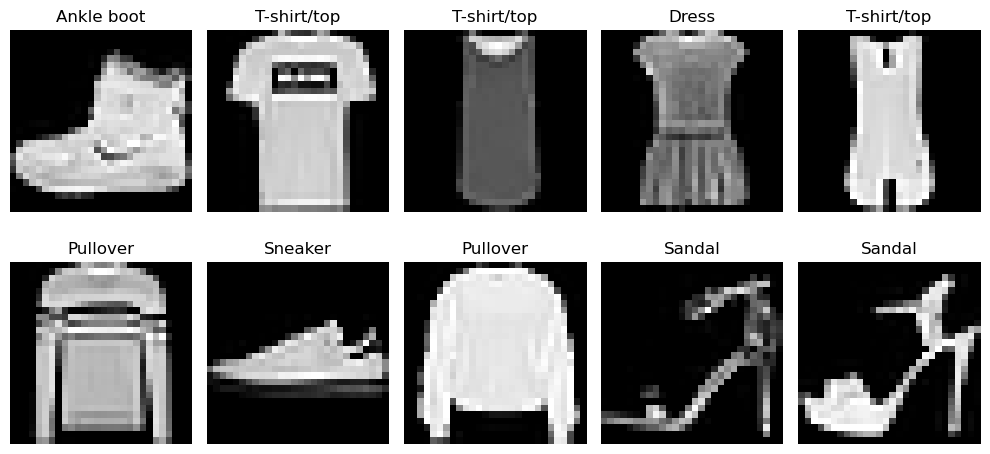

In [6]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = X_train[i].reshape(28, 28)

    plt.imshow(image, cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
print("Training Linear SVM...")

start_time = time.time()

linear_svm = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

linear_svm.fit(X_train, y_train)

linear_train_time = time.time() - start_time

print("Linear SVM training completed.")
print("Training time:", linear_train_time, "seconds")


Training Linear SVM...
Linear SVM training completed.
Training time: 94.32093620300293 seconds


In [8]:
start_time = time.time()

y_pred_linear = linear_svm.predict(X_test)

linear_prediction_time = time.time() - start_time

linear_accuracy = accuracy_score(
    y_test,
    y_pred_linear
)

print("Linear SVM Accuracy:", linear_accuracy)
print("Prediction time:", linear_prediction_time, "seconds")


Linear SVM Accuracy: 0.8402
Prediction time: 0.11383247375488281 seconds


In [9]:
print("Training RBF SVM...")

start_time = time.time()

rbf_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

rbf_svm.fit(X_train, y_train)

rbf_train_time = time.time() - start_time

print("RBF SVM training completed.")
print("Training time:", rbf_train_time, "seconds")


Training RBF SVM...
RBF SVM training completed.
Training time: 323.3245279788971 seconds


In [14]:
start_time = time.time()

y_pred_rbf = rbf_svm.predict(X_test)

rbf_prediction_time = time.time() - start_time

rbf_accuracy = accuracy_score(
    y_test,
    y_pred_rbf
)

print("RBF SVM Accuracy:", rbf_accuracy)
print("Prediction time:", rbf_prediction_time, "seconds")

results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM"
    ],

    "Accuracy": [
        linear_accuracy,
        rbf_accuracy
    ],

    "Training Time (seconds)": [
        linear_train_time,
        rbf_train_time
    ],

    "Prediction Time (seconds)": [
        linear_prediction_time,
        rbf_prediction_time
    ]
})

print(results)


RBF SVM Accuracy: 0.9002
Prediction time: 136.97261762619019 seconds
        Model  Accuracy  Training Time (seconds)  Prediction Time (seconds)
0  Linear SVM    0.8402                94.320936                   0.113832
1     RBF SVM    0.9002               323.324528                 136.972618


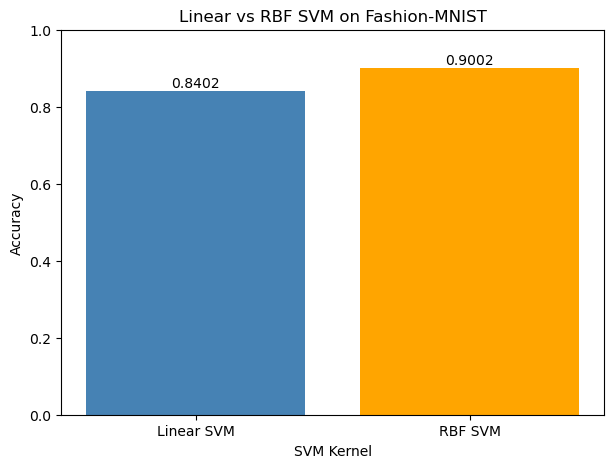

In [15]:
models = ["Linear SVM", "RBF SVM"]

accuracies = [
    linear_accuracy,
    rbf_accuracy
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    models,
    accuracies,
    color=["steelblue", "orange"]
)

plt.ylabel("Accuracy")
plt.xlabel("SVM Kernel")
plt.title("Linear vs RBF SVM on Fashion-MNIST")
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.01,
        f"{accuracy:.4f}",
        ha="center"
    )

plt.show()


In [16]:
print("===== Linear SVM =====")

print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=class_names
    )
)
print("===== RBF SVM =====")

print(
    classification_report(
        y_test,
        y_pred_rbf,
        target_names=class_names
    )
)


===== Linear SVM =====
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.82      0.80      1000
     Trouser       0.97      0.95      0.96      1000
    Pullover       0.72      0.73      0.72      1000
       Dress       0.82      0.86      0.84      1000
        Coat       0.72      0.78      0.75      1000
      Sandal       0.94      0.92      0.93      1000
       Shirt       0.65      0.51      0.57      1000
     Sneaker       0.91      0.94      0.92      1000
         Bag       0.92      0.94      0.93      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

===== RBF SVM =====
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.84  

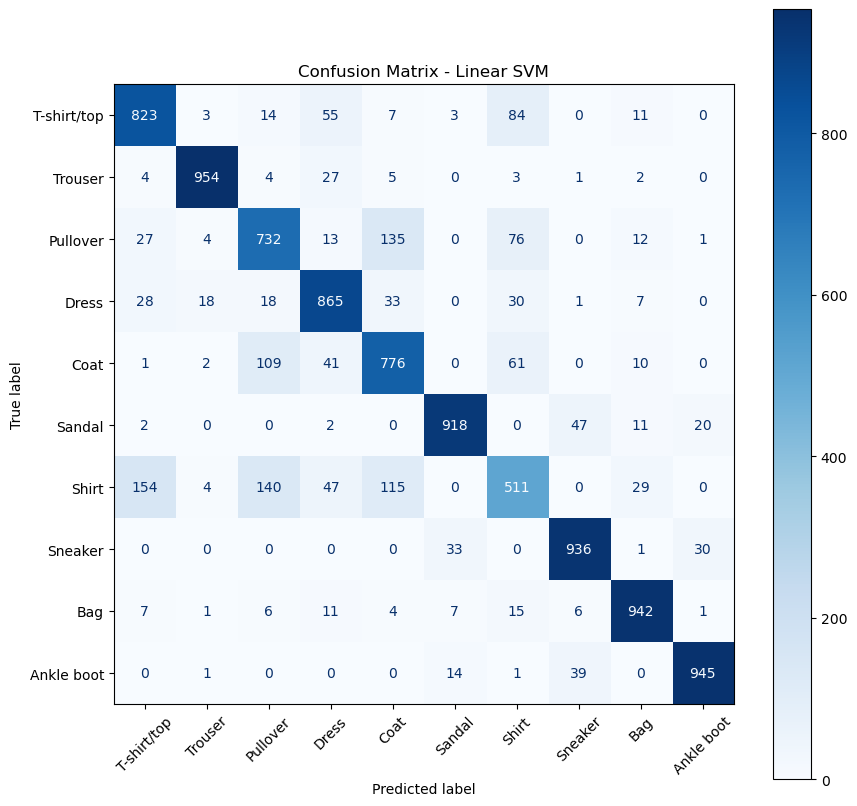

In [17]:
cm_linear = confusion_matrix(
    y_test,
    y_pred_linear
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Linear SVM")
plt.show()


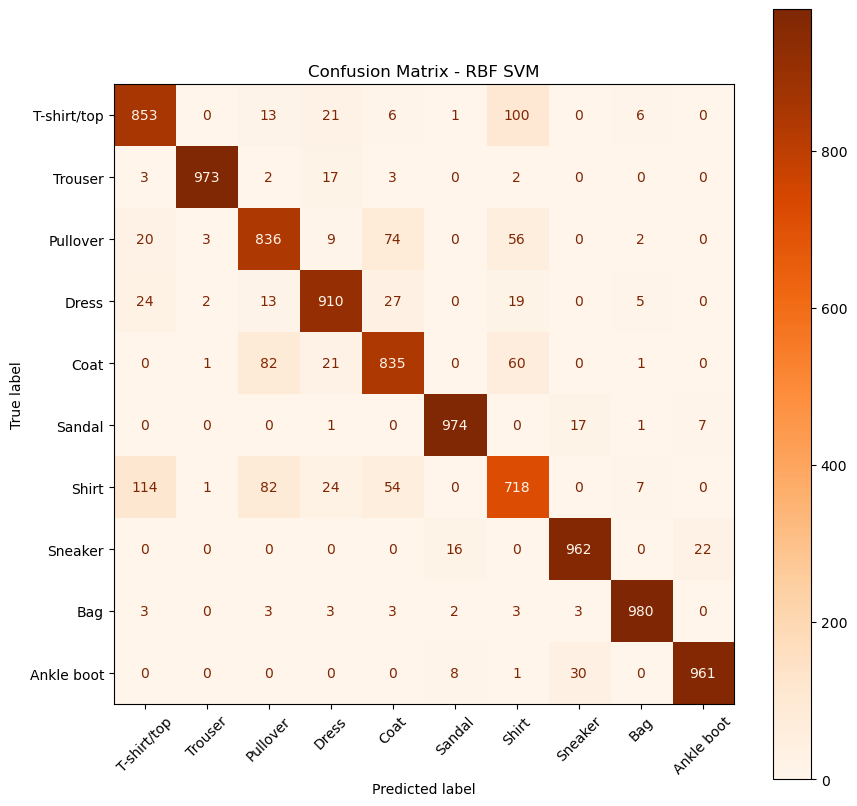

In [18]:
cm_rbf = confusion_matrix(
    y_test,
    y_pred_rbf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rbf,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    cmap="Oranges",
    xticks_rotation=45
)

plt.title("Confusion Matrix - RBF SVM")
plt.show()
